## Pneumonia Classification CNN

#### COMP4388: Machine Learning
#### Abduallah Aabed

### Introduction

In this project I'm using Convolutional Neural Networks to classify images into pre-defined categories. The task is to train a model that will detect if a chest x-ray image is diagnosed with Pneumonia or not.

### Background and theory

First of, let's simply understand the Pneumonia and existing solutions for it's classifications.

### Medical Defention, quick symptons and causes
**Pneumonia** is an inflammatory infection of the lungs' air sacs that causes them to fill with fluid or pus, resulting in symptoms ranging from a productive cough and chest pain to fever, chills, and difficulty breathing. It is primarily caused by infectious agents such as bacteria, viruses, and fungi, or by the accidental aspiration of food or liquids into the lungs. While many cases present as a severe flu-like illness, the condition can be life-threatening, particularly for infants, adults over 65, and those with weakened immune systems or chronic respiratory conditions. [1]

### Solutions in classification for Pneumonia

#### 1. Traditional Machine learning 
Like most of image classification problems, before deep learning, solutions have relied om Traditional Machine Learning solution. the reserach manually worked on feature engineering to specify the patterns in infected lungs like texture and shape, then they used the extracted features to feed to traditional ML algortihms like SVM and KNNs.

These solution are limited to capture the complex patterns in the images.

#### 2. CNN
After convultional neural networks CNNs there was no need to manually do the feature extractions. The development and design of CNN layers has allowed to use the pre-trained models and improve and result on high accuracy. However, this solution requires large datasets.

#### 3. Transformers

Transformers currently results in higher accuracy and it requires a high compuatioanl cost.

### Dataset:
- The dataset that used in this work is the Chest X-Ray dataset.downloaded through the row images of the dataset here Version (roboflow.com). https://universe.roboflow.com/mohamed-traore-2ekkp/chest-x-rays-qjmia/dataset/4
  
- Since the environment used to run this code is on kaggle, I have utilized the same dataset uploaded to kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia [1]

The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). 

There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal). 


Here is an example from the dataset on how the Pneumonia actually looks like in the x-ray:


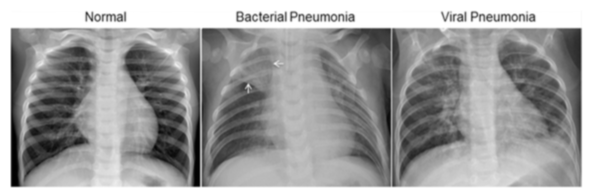


The Dataset original source is: https://data.mendeley.com/datasets/rscbjbr9sj/2

Under License: CC BY 4.0

Citation: http://www.cell.com/cell/fulltext/S0092-8674(18)30154-5

### Tools

Kaggle environemnt, 

## Important libaries for this project

To run this project the following is imported

In [1]:
import numpy as np
import pandas as pd 
import os
import pandas as pd
import random
import math
import PIL
import PIL.Image as Image
import cv2
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

2026-01-26 17:44:01.033585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769449441.508495      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769449441.639530      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769449442.844842      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769449442.844882      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769449442.844884      24 computation_placer.cc:177] computation placer alr

#### loading the dataset into dataframe

In [2]:
def load_dataset(base_path):
    """
    read the dataset into datafarem
    """
    all_filepaths = []
    all_labels = []
    
    splits = ['train', 'test', 'val'] ## based on kaggle directories

    for split in splits:
        split_path = os.path.join(base_path, split)
        
        if not os.path.exists(split_path):
            continue

        for folder in os.listdir(split_path):
            label_path = os.path.join(split_path, folder)
            
            if os.path.isdir(label_path):
                for image in os.listdir(label_path):
                    if image.lower().endswith(('.jpeg', '.jpg', '.png')):
                        all_filepaths.append(os.path.join(label_path, image))
                        all_labels.append(folder)

    df = pd.DataFrame({
        'ImagePath': all_filepaths,
        'Label': all_labels
    })

    return df

In [3]:
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'
df = load_dataset(base_path)

#### split the dataset

In [4]:
# Split 80% Train, 10% Val, 10% Test
train_df, rem_df = train_test_split(df, train_size=0.8, stratify=df['Label'], random_state=42)
val_df, test_df = train_test_split(rem_df, train_size=0.5, stratify=rem_df['Label'], random_state=42)

In [5]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [6]:
print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print(f"Testing Samples: {len(test_df)}")

Training Samples: 4684
Validation Samples: 586
Testing Samples: 586


#### Looking into samples

In [7]:
train_df.sample(10)

,ImagePath,Label
2321,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
2659,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1473,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
1732,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4410,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1419,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
798,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4502,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
4143,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3271,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA


In [8]:
train_df['Label'].value_counts()

Label
PNEUMONIA    3418
NORMAL       1266
Name: count, dtype: int64

In [9]:
val_df['Label'].value_counts()

Label
PNEUMONIA    427
NORMAL       159
Name: count, dtype: int64

In [10]:
test_df['Label'].value_counts()

Label
PNEUMONIA    428
NORMAL       158
Name: count, dtype: int64

class imbalance.  "Normal" class is much smaller than  "Pneumonia" class.

In [11]:
def show_random_samples(df, num=8):
    """
    Shows a random sample of images from the dataframe.
    """
    sample_df = df.sample(num)
    cols = 4
    rows = (num + cols - 1) // cols
    
    plt.figure(figsize=(20, rows * 5))
    
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(row['ImagePath'])
        plt.imshow(img, cmap='gray')
        plt.title(f"Diagnosis: {row['Label']}\n(Index: {idx})")
        plt.axis('off')
        
    plt.suptitle("Random Sample of the Dataset", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

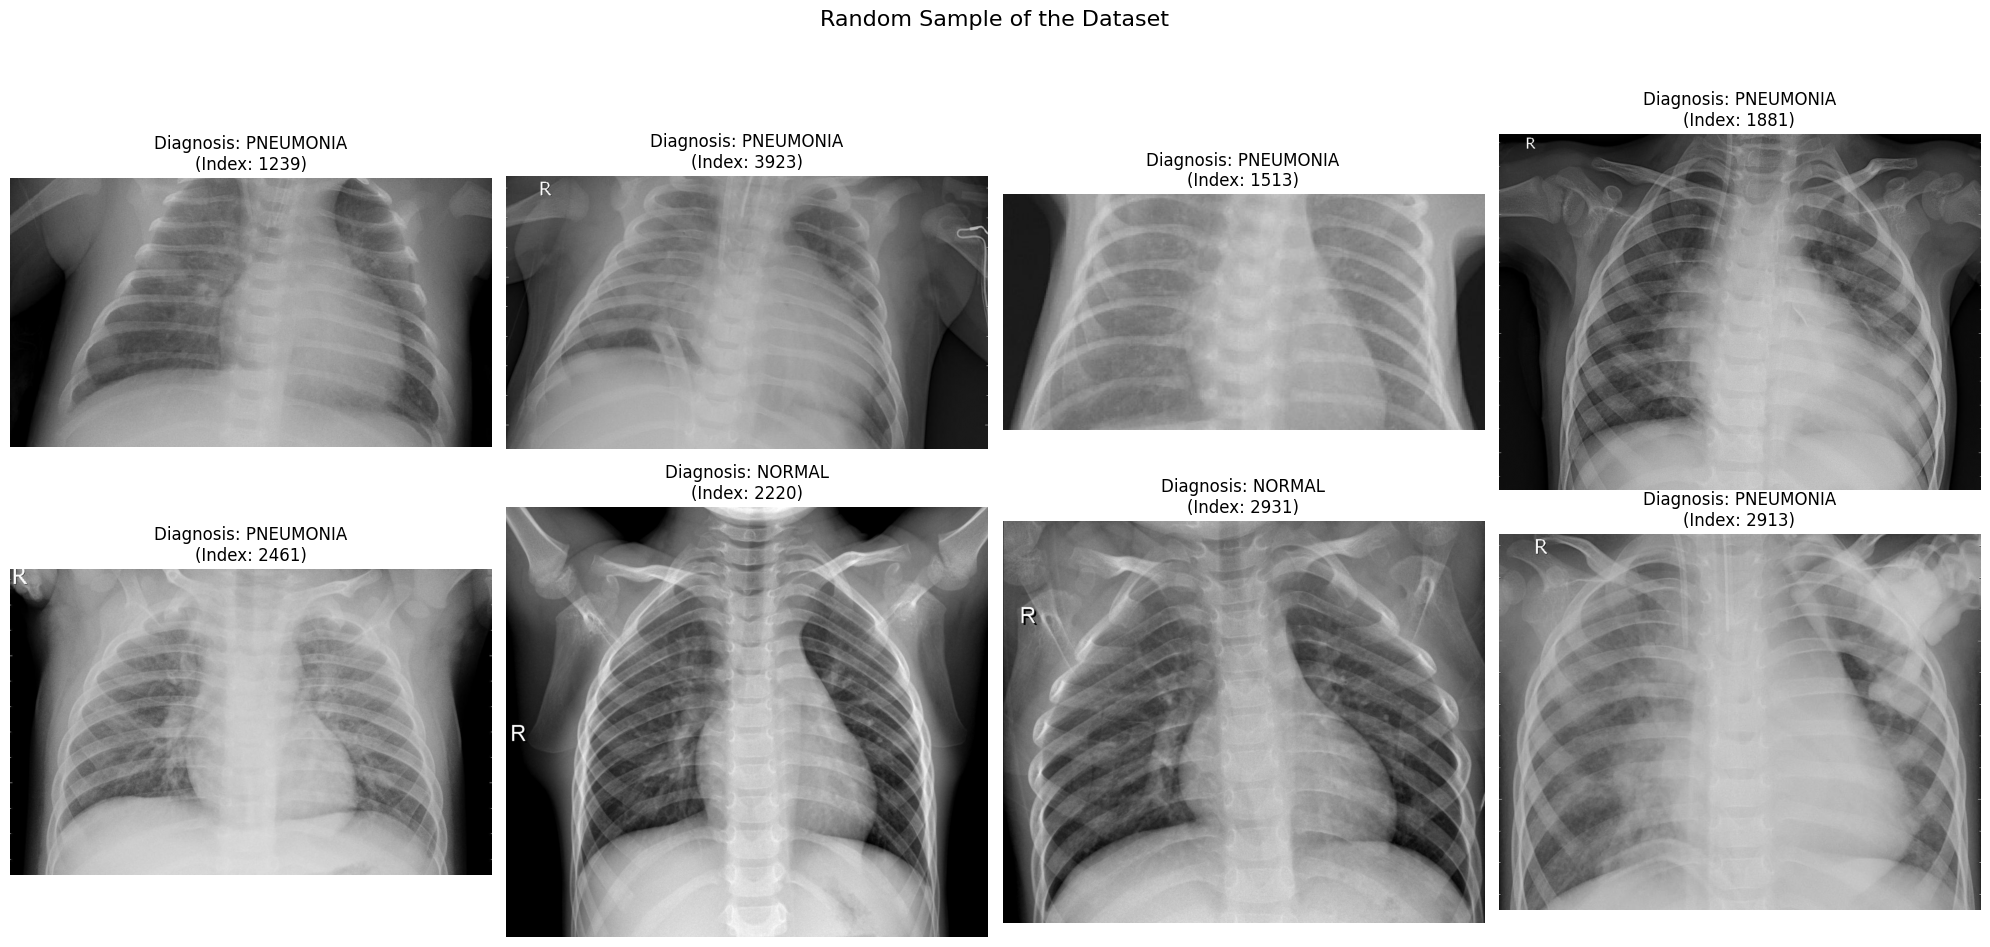

In [12]:
show_random_samples(train_df, 8)

- The samples shows diffrent sizes of images in grey scale 

- Let's take a look into each image attributes

The width of the images:  1438
The height of the images:  1140
Shape (1438, 1140)


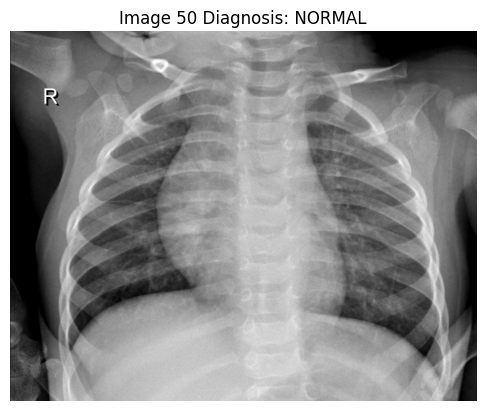

In [13]:
image_path =  train_df.loc[50, "ImagePath"]
image = PIL.Image.open(image_path)
plt.imshow(image, cmap='gray')
plt.title(f"Image {50} Diagnosis: {train_df.loc[50, 'Label']}")
plt.axis("off")
width, height = image.size
print("The width of the images: ", width)
print("The height of the images: ", height)
print("Shape", image.size)

The width of the images:  1320
The height of the images:  976
Shape (1320, 976)


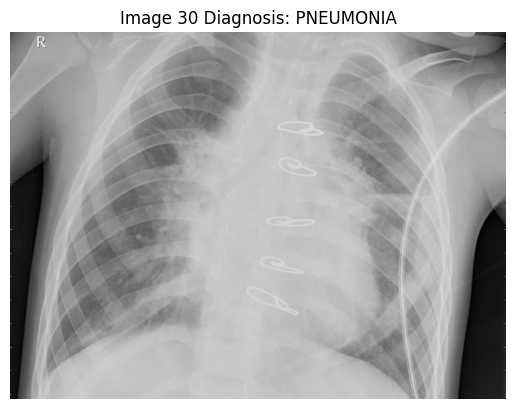

In [14]:
image_path =  train_df.loc[30, "ImagePath"]
image = PIL.Image.open(image_path)
plt.imshow(image, cmap='gray')
plt.title(f"Image {30} Diagnosis: {train_df.loc[30, 'Label']}")
plt.axis("off")
width, height = image.size
print("The width of the images: ", width)
print("The height of the images: ", height)
print("Shape", image.size)

- The two samples shows diffrent sizes from each class

- Let's look at the distribution of the images sizes and ratios

In [15]:
image_sizes = []
aspect_ratios = []

for image_path in train_df['ImagePath']:
    image = PIL.Image.open(image_path)
    width, height = image.size
    image_sizes.append(width * height)
    aspect_ratios.append(width / height)

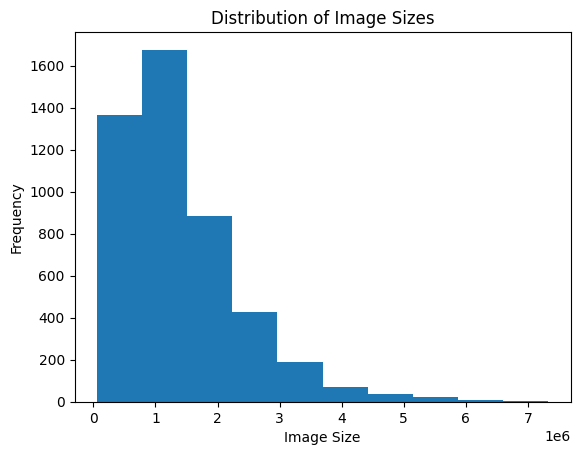

In [16]:
plt.hist(image_sizes, label="Image Size")
plt.title("Distribution of Image Sizes")
plt.xlabel("Image Size")
plt.ylabel("Frequency");

- Most images are quite large

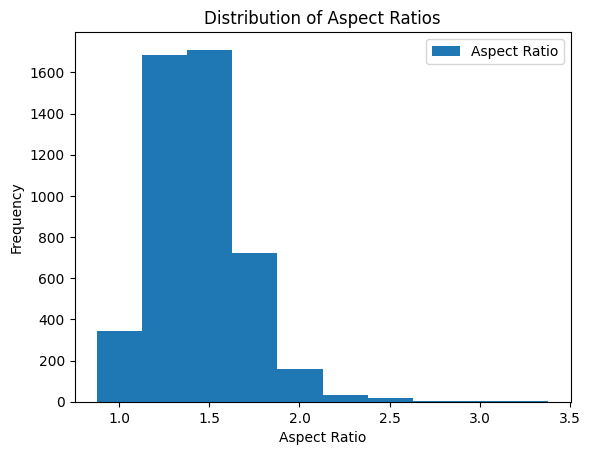

In [17]:
plt.hist(aspect_ratios, label="Aspect Ratio")
plt.title("Distribution of Aspect Ratios")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")
plt.legend();

Most images are not square; they are roughly 1.3 to 1.6 (wider than they are tall).

---> Based on these data results, the following preprocessing will be done prior training

### Images preprocessing

- For image resize, I have tried the normal resizing which results in distortion and stretching in the aspect ratio, so then I tested with padding and keeping the aspect ratio which resulted in better results:
- the IMG_SIZE is set to 224 which standard size for CNN tasks

In [18]:
IMG_SIZE = 224

In [19]:
def preprocess_image(path):
    """
    Takes the path image and resize keeping aspect ratio with centralized padding
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None

    # Calculate the scale and new dimensions
    h, w = img.shape[:2]
    scale = IMG_SIZE / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Calculate padding for making image in centering
    delta_w = IMG_SIZE - new_w
    delta_h = IMG_SIZE - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)  # Apply padding (value=0 for black) for better results
    img = img / 255.0 # Normalization: scales pixels to [0, 1]
    img = np.expand_dims(img, axis=-1) # Add channel dimension for the CNN (Height, Width, 1)
    return img

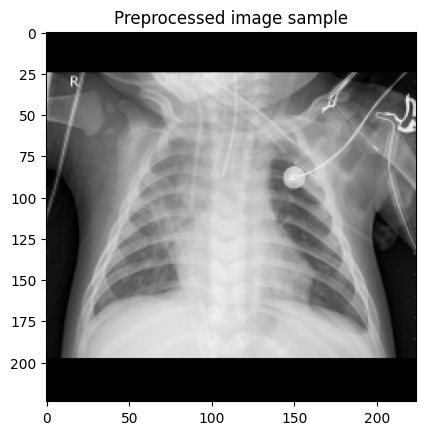

In [20]:
plt.imshow(preprocess_image(train_df.iloc[100]['ImagePath']), cmap="gray")
plt.title("Preprocessed image sample")
plt.show();

### Labels preprocsining

In [21]:
le = LabelEncoder() ## will be using the same encoder

In [22]:
def prepare_dataset(df, encoder, is_training=True):
    """
    Final wrapper to process both labels and images for a specific split.
    
    Args:
        df (pd.DataFrame): The split dataframe (train, val, or test).
        encoder (LabelEncoder): The LabelEncoder.
        is_training (bool): If True, fits the encoder. If False, only transforms.
        
    Returns:
        X (np.array): Preprocessed image array.
        y (np.array): Encoded label array.
    """
    # 1. Process Labels
    if is_training:
        df['Label_Num'] = encoder.fit_transform(df['Label'])
    else:
        df['Label_Num'] = encoder.transform(df['Label'])
    
    # 2. Process Images
    num_samples = len(df)
    preprocessed_images = []
    
    for i in range(num_samples):
        img_path = df['ImagePath'].iloc[i]
        image = preprocess_image(img_path) 
        preprocessed_images.append(image)
    
    X = np.array(preprocessed_images)
    y = np.array(df['Label_Num'])
    
    return X, y

The current split is 80% train, 10% test and 10% validation

In [23]:
# Prepare (preprocess ) each split 
X_train, y_train = prepare_dataset(train_df, le, is_training=True)
X_val, y_val     = prepare_dataset(val_df, le, is_training=False)
X_test, y_test   = prepare_dataset(test_df, le, is_training=False)

- ensuring the shapes are ready for expiremnts

In [24]:
print(f" Train Set: {X_train.shape}") 
print(f" Validation set: {X_val.shape}") 
print(f" Test Set Shape: {X_test.shape}") 

 Train Set: (4684, 224, 224, 1)
 Validation set: (586, 224, 224, 1)
 Test Set Shape: (586, 224, 224, 1)



### Main Task:
- The main task is to Train a CNN model. 
- The design is either my own architecture or use existing architecture. 
- the architecture details is specified used either you designed it or cite existing literature on what did you use.

#### Requested model (Model_A)

This model is required to do the training on, which is consist of the following layers, very basic and simple:
    - 1 convolutional layer (non-overlapping filters), 
    - 1 average pooling layer, 
    - fully connected NN.

In [25]:
def build_required_model(input_shape=(224, 224, 1)):
    """
    This function returns the required model architucture by the assignment
    """
    model = models.Sequential()

    # 1. Convolutional Layer with non-overlapping filters
    model.add(layers.Conv2D(32, kernel_size=(4, 4), strides=(4, 4), 
                            activation='relu', input_shape=input_shape))

    # 2. Average Pooling Layer
    model.add(layers.AveragePooling2D(pool_size=(2, 2)))

    # 3. Fully Connected NN
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5)) 
    
    # Output layer 
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam',
              loss='binary_crossentropy',
             metrics=['accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')])
    
    return model

In [26]:
model_a = build_required_model()

model_a.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1769449609.284338      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769449609.288259      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 56, 56, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 28, 28, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,212,065 (12.25 MB)

 Trainable params: 3,212,065 (12.25 MB)

 Non-trainable params: 0 (0.00 B)

### Training Model A

In [27]:
history = model_a.fit(np.array(X_train), y_train, 
                            validation_data=(np.array(X_val), y_val), 
                    epochs=25, batch_size=32)

Epoch 1/25


I0000 00:00:1769449616.224851      71 service.cc:152] XLA service 0x7a73f00232c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769449616.224918      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769449616.224929      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769449616.651453      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


 30/147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7530 - loss: 0.4986 - precision: 0.8079 - recall: 0.8539

I0000 00:00:1769449619.735883      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/147 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8248 - loss: 0.3934 - precision: 0.8574 - recall: 0.9095 - val_accuracy: 0.8959 - val_loss: 0.2606 - val_precision: 0.8910 - val_recall: 0.9766
Epoch 2/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8870 - loss: 0.2704 - precision: 0.9059 - recall: 0.9429 - val_accuracy: 0.9215 - val_loss: 0.2141 - val_precision: 0.9243 - val_recall: 0.9719
Epoch 3/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9078 - loss: 0.2223 - precision: 0.9220 - recall: 0.9544 - val_accuracy: 0.9352 - val_loss: 0.1787 - val_precision: 0.9642 - val_recall: 0.9461
Epoch 4/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9271 - loss: 0.1947 - precision: 0.9431 - recall: 0.9577 - val_accuracy: 0.9420 - val_loss: 0.1759 - val_precision: 0.9559 - val_recall: 0.9649
Epoch 5/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9238 - loss: 0.1910 - precision: 0.9420 - recall: 0.9539 - val_accuracy: 0.9420 - val_loss: 0.1570 - val

### Testing Model A

In [28]:
model_a.save("model_a.keras")
reconstructed_model = load_model("model_a.keras")
reconstructed_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')])

test_loss_a, test_acc_a,test_recall_a, precision_a = reconstructed_model.evaluate(X_test, y_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9537 - loss: 0.1583 - precision: 0.9597 - recall: 0.9776


#### Results of test for Model A:

- accuracy = 95.15%
- loss: 0.1848
- precision: 0.9473
- recall: 0.9885

#### Confusion matrix Model A

- Class confusion matrix
    Provide the Class confusion matrix of the classification output for both classifiers.


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


<Figure size 800x600 with 0 Axes>

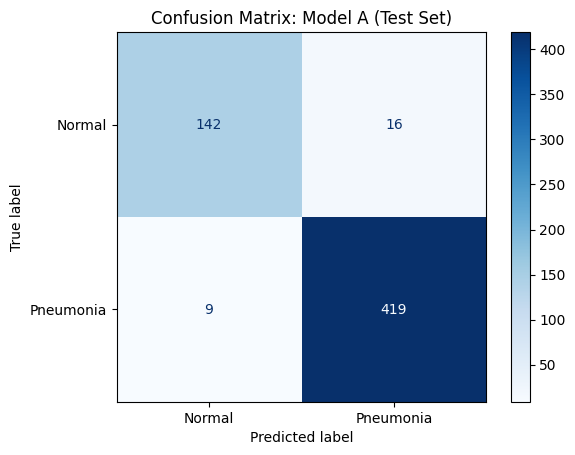

False Positives (Healthy misidentified as Sick): 16
False Negatives (Sick cases missed): 9


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate predictions (probabilities)
y_pred_probs = reconstructed_model.predict(np.array(X_test))

# 2. Convert probabilities to binary classes (0 or 1)
# Using 0.5 as the standard threshold
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot the matrix using Seaborn/Matplotlib for a professional look
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Pneumonia'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix: Model A (Test Set)')
plt.show()

# 5. Print a text-based summary of mistakes
tn, fp, fn, tp = cm.ravel()
print(f"False Positives (Healthy misidentified as Sick): {fp}")
print(f"False Negatives (Sick cases missed): {fn}")

#### Requested model (Model_B)

This model is a proposed model to do the training on, which is consist of the following layers, more complex:


In [30]:
def build_proposed_model(input_shape=(224, 224, 1)):
    
    model = models.Sequential([
        # --- Data Augmentation Block ---

        layers.RandomFlip("horizontal", input_shape=input_shape),
        layers.RandomZoom(0.1),     
        
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 4
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
          loss='binary_crossentropy',
         metrics=['accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')])
    
    return model

In [31]:
model_b = build_proposed_model()

model_b.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [32]:
history_b = model_b.fit( X_train, y_train, validation_data=(X_val, y_val),
    epochs=50, batch_size=64,shuffle=True)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 267ms/step - accuracy: 0.8104 - loss: 0.4258 - precision: 0.8449 - recall: 0.9100 - val_accuracy: 0.7287 - val_loss: 0.6600 - val_precision: 0.7287 - val_recall: 1.0000
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 246ms/step - accuracy: 0.8733 - loss: 0.2880 - precision: 0.9009 - recall: 0.9276 - val_accuracy: 0.7287 - val_loss: 0.9936 - val_precision: 0.7287 - val_recall: 1.0000
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 249ms/step - accuracy: 0.8945 - loss: 0.2668 - precision: 0.9236 - recall: 0.9340 - val_accuracy: 0.7287 - val_loss: 1.1048 - val_precision: 0.7287 - val_recall: 1.0000
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 251ms/step - accuracy: 0.9054 - loss: 0.2340 - precision: 0.9311 - recall: 0.9411 - val_accuracy: 0.7287 - val_loss: 1.0021 - val_precision: 0.7287 - val_recall: 1.0000
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 255ms/step - accuracy: 0.9138 - loss: 0.2307 - precision: 0.9358 - recall: 0.9467 - val_accuracy: 0.7287 - val_los

### Tesing Model B

In [33]:
model_b.save("model_b.keras")
reconstructed_model_b = load_model("model_b.keras")
reconstructed_model_b.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')])

test_loss_b, test_acc_b,test_recall_b, precision_b = reconstructed_model_b.evaluate(X_test, y_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9599 - loss: 0.1204 - precision: 0.9563 - recall: 0.9904


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


<Figure size 800x600 with 0 Axes>

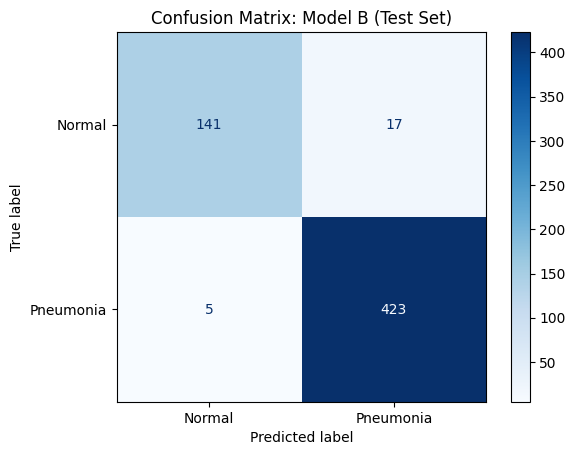

False Positives (Healthy misidentified as Sick): 17
False Negatives (Sick cases missed): 5


In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Generate predictions (probabilities)
y_pred_probs_b = reconstructed_model_b.predict(np.array(X_test))

# 2. Convert probabilities to binary classes (0 or 1)
# Using 0.5 as the standard threshold
y_pred_b = (y_pred_probs_b > 0.5).astype(int)

# 3. Create the confusion matrix
cm_b = confusion_matrix(y_test, y_pred_b)

# 4. Plot the matrix using Seaborn/Matplotlib for a professional look
plt.figure(figsize=(8, 6))
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=['Normal', 'Pneumonia'])
disp_b.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix: Model B (Test Set)')
plt.show()

# 5. Print a text-based summary of mistakes
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
print(f"False Positives (Healthy misidentified as Sick): {fp_b}")
print(f"False Negatives (Sick cases missed): {fn_b}")

### Models Comparisons

In this section, we look into comparing the models in terms of the following metrics:
- the Accuracy,
- Precision, 
- Recall, 
- F1-Score of

In [35]:
def plot_training_history(history):
    """
    
    """
    epochs = range(1, len(history.history['loss']) + 1)
    metrics = [
        ('loss', 'Loss'), 
        ('accuracy', 'Accuracy'), 
        ('precision', 'Precision'), 
        ('recall', 'Recall')
    ]
    
    plt.figure(figsize=(16, 12))
    
    for i, (key, name) in enumerate(metrics, 1):
        plt.subplot(2, 2, i)
        plt.plot(epochs, history.history[key], 'b-o', label=f'Training {name}', markersize=4)
        plt.plot(epochs, history.history[f'val_{key}'], 'r-s', label=f'Validation {name}', markersize=4)
        plt.title(f'Figure {10+i}: {name} Learning Curve', fontsize=14)
        plt.xlabel('Epochs')
        plt.ylabel(name)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

    plt.tight_layout()
    plt.show()

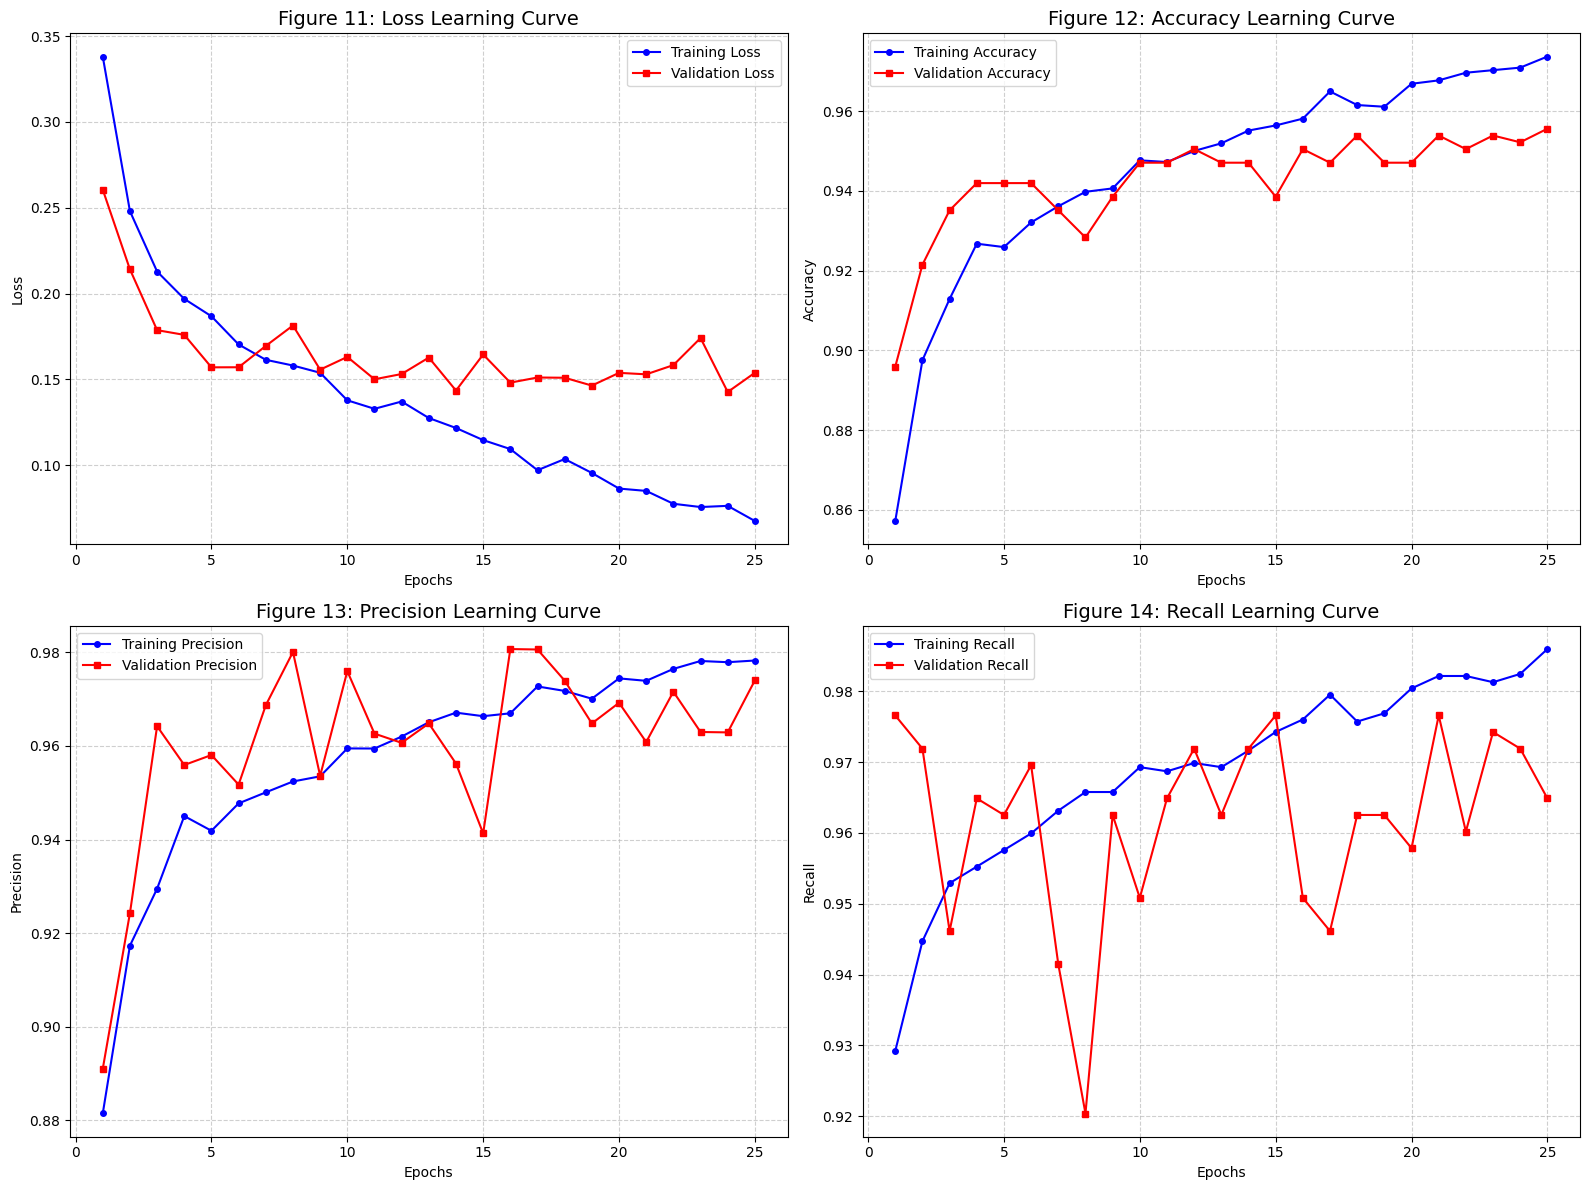

In [36]:
plot_training_history(history)

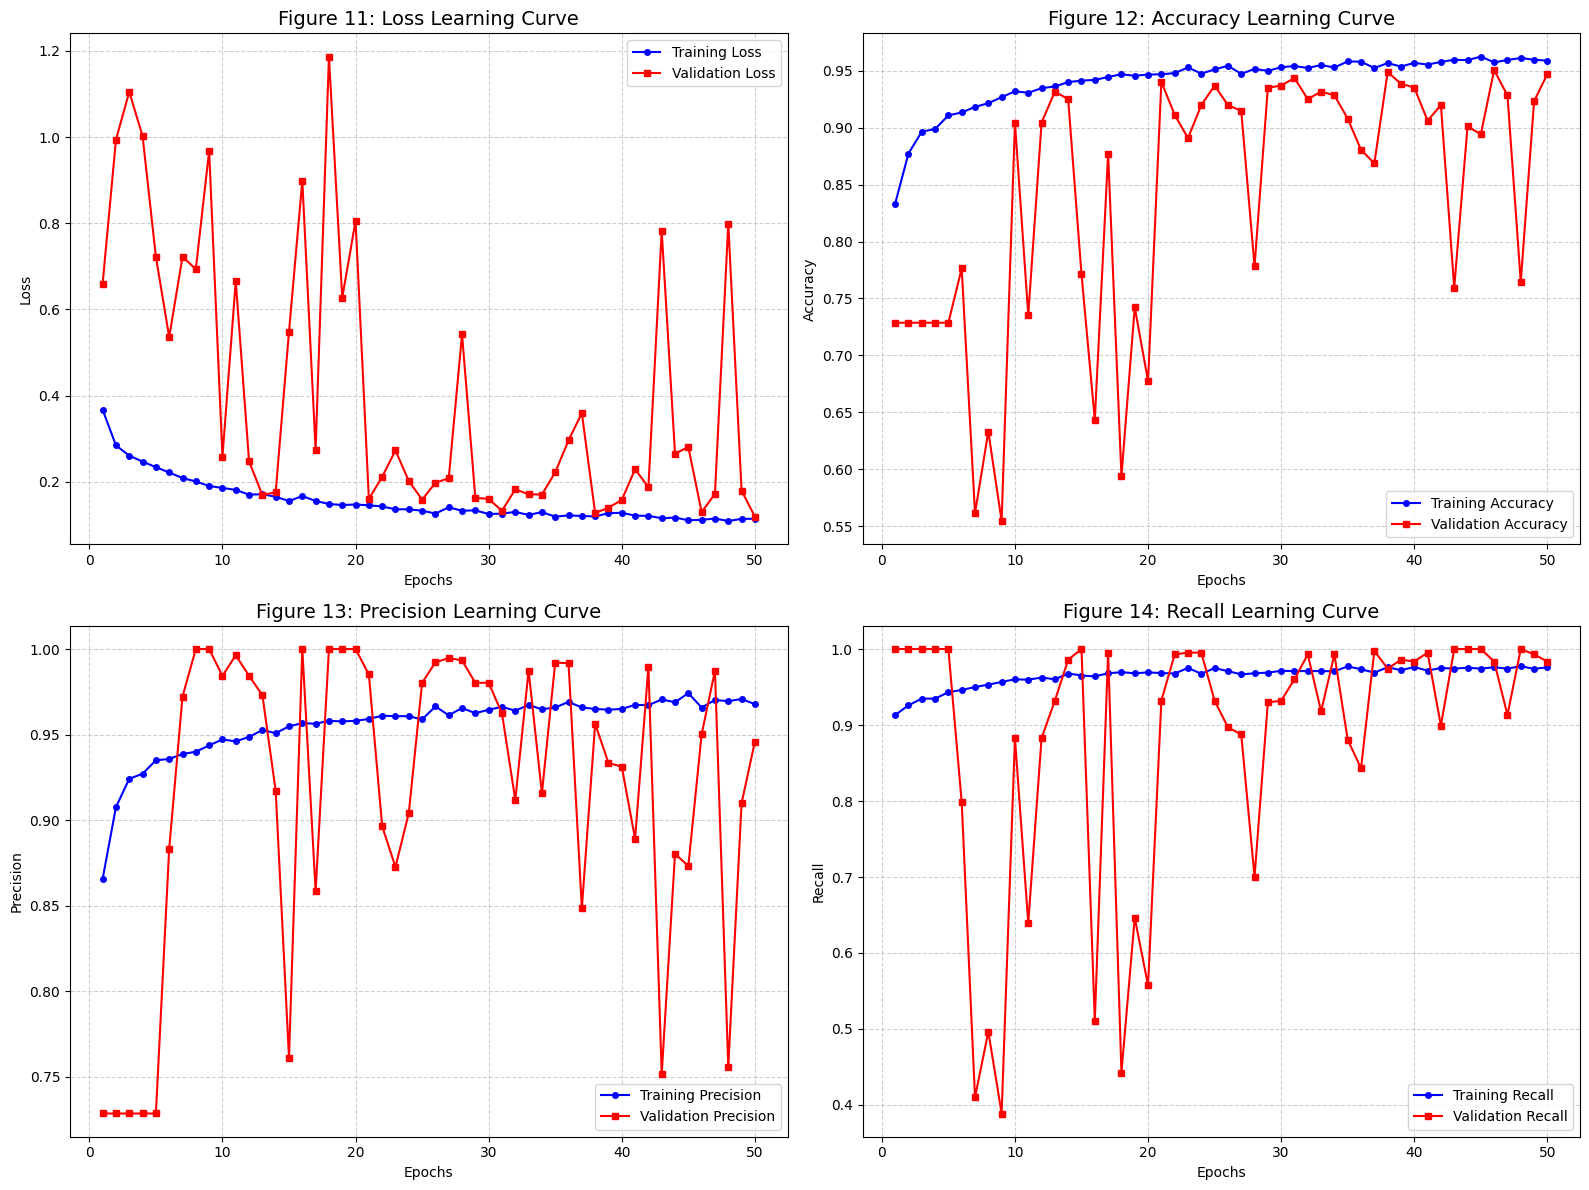

In [37]:
plot_training_history(history_b)


### Discussions
In this Report the results and experiments are shown, provided the following: 

- Insights and interpretations of the results ().


## Refrences:
- [1] Dataset: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia 
- [2] https://www.mayoclinic.org/diseases-conditions/pneumonia/symptoms-causes/syc-20354204